ЗАГРУЗКА И АНАЛИЗ ЭЭГ ДАННЫХ (ИСПРАВЛЕННАЯ ВЕРСИЯ)

1. Загрузка аннотаций из файла 'annotations_2017_A.csv'
   Количество секунд с аннотациями: 15416
   Первое появление метки приступа: 0 сек
   Суммы меток в первых 10 секундах: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8]

2. Загрузка EDF-файла 'eeg44.edf'
Extracting EDF parameters from eeg44.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 860159  =      0.000 ...  3359.996 secs...
   Частота дискретизации: 256.0 Гц
   Длительность записи: 3360.00 сек (~56.0 мин)
   Все каналы: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF', 'ECG EKG-REF', 'Resp Effort-REF']

3. Выбор только ЭЭГ-каналов
   Найдено ЭЭГ-каналов: 19
   Список ЭЭГ-каналов: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 

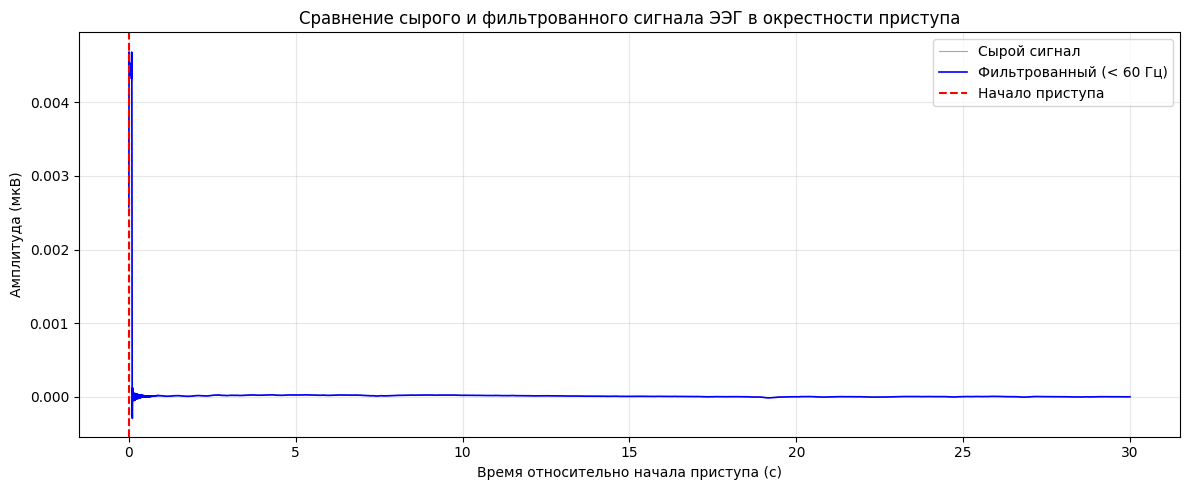

   График временного сигнала сохранён как 'eeg_time_signal_corrected.png'


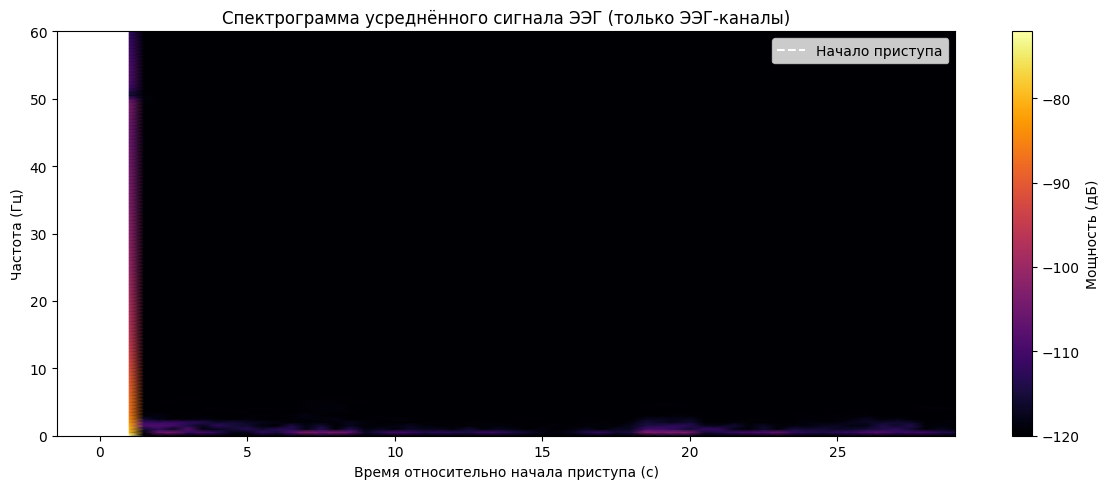

   Спектрограмма сохранена как 'eeg_spectrogram_corrected.png'

7. Вычисление вейвлет-преобразования (Морле)


C:\Users\GH\AppData\Local\Temp\ipykernel_11880\2504094089.py:210: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


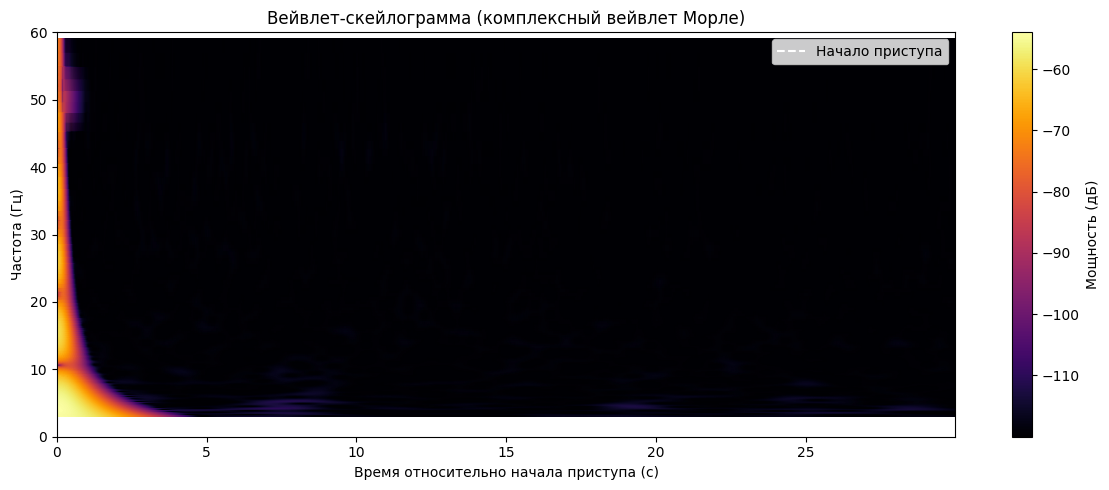

   Вейвлет-скейлограмма сохранена как 'eeg_wavelet_scalogram_corrected.png'

ВЫПОЛНЕНИЕ ЗАДАНИЯ ЗАВЕРШЕНО (С ИСПРАВЛЕНИЯМИ)


In [1]:
# -*- coding: utf-8 -*-
"""
EEG Analysis with Corrections:
- Use only EEG channels (exclude ECG, Resp)
- Time window includes 10 seconds before seizure
- Proper filtering and visualization
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne
from scipy.signal import butter, filtfilt, spectrogram
import pywt

print("=" * 60)
print("ЗАГРУЗКА И АНАЛИЗ ЭЭГ ДАННЫХ (ИСПРАВЛЕННАЯ ВЕРСИЯ)")
print("=" * 60)

# ------------------------------------------------------------
# 1. Загрузка аннотаций и определение момента приступа
# ------------------------------------------------------------
print("\n1. Загрузка аннотаций из файла 'annotations_2017_A.csv'")
annotations = pd.read_csv('annotations_2017_A.csv', header=None)
# Первая строка — номера колонок (1..79), пропускаем её
annotations = annotations.iloc[1:].reset_index(drop=True)
# Заменяем пропуски (NaN) нулями и преобразуем в целые
annotations = annotations.fillna(0).astype(int)

# Анализ меток: сумма значений в каждой секунде
row_sums = annotations.sum(axis=1)
# Находим первый момент времени, где сумма > 0
seizure_start_idx = np.where(row_sums > 0)[0][0]
seizure_start_sec = seizure_start_idx  # каждая строка = 1 секунда

print(f"   Количество секунд с аннотациями: {len(row_sums)}")
print(f"   Первое появление метки приступа: {seizure_start_sec} сек")
print(f"   Суммы меток в первых 10 секундах: {row_sums[:10].tolist()}")

# ------------------------------------------------------------
# 2. Загрузка EDF-файла с помощью MNE
# ------------------------------------------------------------
print("\n2. Загрузка EDF-файла 'eeg44.edf'")
edf_path = 'eeg44.edf'
raw = mne.io.read_raw_edf(edf_path, preload=True)

fs = raw.info['sfreq']
total_duration = raw.n_times / fs
print(f"   Частота дискретизации: {fs} Гц")
print(f"   Длительность записи: {total_duration:.2f} сек (~{total_duration/60:.1f} мин)")
print(f"   Все каналы: {raw.ch_names}")

# ------------------------------------------------------------
# 3. Выбор только ЭЭГ-каналов (исключаем ECG, Resp и т.д.)
# ------------------------------------------------------------
print("\n3. Выбор только ЭЭГ-каналов")
# Способ 1: по префиксу 'EEG'
eeg_channels = [ch for ch in raw.ch_names if ch.startswith('EEG')]
print(f"   Найдено ЭЭГ-каналов: {len(eeg_channels)}")
print(f"   Список ЭЭГ-каналов: {eeg_channels}")

# Альтернативный способ через mne.pick_types (более надёжный)
picks = mne.pick_types(raw.info, meg=False, eeg=True, ecg=False, resp=False, eog=False)
eeg_channels_mne = [raw.ch_names[i] for i in picks]
print(f"   Каналы, выбранные mne.pick_types: {eeg_channels_mne}")

# Используем первый способ (по префиксу) для явности
raw_eeg = raw.copy().pick_channels(eeg_channels)
data, times = raw_eeg[:, :]  # (n_eeg_channels, n_samples)
n_eeg = len(eeg_channels)
print(f"   Форма данных ЭЭГ: {data.shape}")

# ------------------------------------------------------------
# 4. Усреднение по ЭЭГ-каналам
# ------------------------------------------------------------
print("\n4. Усреднение сигнала по ЭЭГ-каналам")
avg_signal = np.mean(data, axis=0)
print(f"   Усреднённый сигнал имеет длину: {len(avg_signal)} отсчётов")

# ------------------------------------------------------------
# 5. Фильтрация: удаление частот выше 60 Гц (ФНЧ)
# ------------------------------------------------------------
print("\n5. Применение ФНЧ с частотой среза 60 Гц")
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

filtered_signal = lowpass_filter(avg_signal, cutoff=60, fs=fs, order=5)
print("   Фильтрация выполнена (фильтр Баттерворта 5-го порядка).")

# (Опционально) Режекторный фильтр для 50 Гц (сетевая наводка)
print("   Дополнительно: удаление 50 Гц (режекторный фильтр)")
from scipy.signal import iirnotch
b_notch, a_notch = iirnotch(50, 30, fs)  # Q=30
filtered_signal = filtfilt(b_notch, a_notch, filtered_signal)
print("   Режекция 50 Гц выполнена.")

# ------------------------------------------------------------
# 6. Выбор временного окна: от 10 секунд ДО приступа до 30 секунд ПОСЛЕ
# ------------------------------------------------------------
pre_seizure = 10   # секунд до приступа (включая отрицательное время)
post_seizure = 30  # секунд после приступа

start_sec = seizure_start_sec - pre_seizure
end_sec   = seizure_start_sec + post_seizure

start_sample = int(start_sec * fs)
end_sample   = int(end_sec * fs)

# Проверка границ
if start_sample < 0:
    print(f"   Внимание: начало окна ({start_sec} сек) выходит за пределы записи. Обрезаем по началу.")
    start_sample = 0
    start_sec = 0
if end_sample > len(avg_signal):
    print(f"   Внимание: конец окна ({end_sec} сек) выходит за пределы записи. Обрезаем по концу.")
    end_sample = len(avg_signal)
    end_sec = end_sample / fs

t_window = times[start_sample:end_sample]
signal_window_raw = avg_signal[start_sample:end_sample]
signal_window_filt = filtered_signal[start_sample:end_sample]

# Время относительно начала приступа (может быть отрицательным)
t_window_rel = t_window - seizure_start_sec

print(f"\n6. Окно анализа: от {t_window_rel[0]:.1f} до {t_window_rel[-1]:.1f} сек относительно приступа")
print(f"   Количество отсчётов в окне: {len(t_window)}")

# ------------------------------------------------------------
# 7. График временной зависимости (сравнение сырого и фильтрованного)
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(t_window_rel, signal_window_raw, 'gray', alpha=0.7, linewidth=0.8, label='Сырой сигнал')
plt.plot(t_window_rel, signal_window_filt, 'b-', linewidth=1.2, label='Фильтрованный (< 60 Гц)')
plt.axvline(0, color='r', linestyle='--', label='Начало приступа')
plt.xlabel('Время относительно начала приступа (с)')
plt.ylabel('Амплитуда (мкВ)')
plt.title('Сравнение сырого и фильтрованного сигнала ЭЭГ в окрестности приступа')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('eeg_time_signal_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print("   График временного сигнала сохранён как 'eeg_time_signal_corrected.png'")

# ------------------------------------------------------------
# 8. Спектрограмма (на фильтрованном сигнале)
# ------------------------------------------------------------
frequencies, spec_times, Sxx = spectrogram(
    signal_window_filt,
    fs=fs,
    nperseg=int(fs * 2),      # окно 2 секунды
    noverlap=int(fs * 1.5),   # перекрытие 75%
    nfft=int(fs * 2)
)

# Временная ось спектрограммы относительно начала приступа
spec_times_rel = spec_times + t_window_rel[0]

plt.figure(figsize=(12, 5))
plt.pcolormesh(spec_times_rel, frequencies,
               10 * np.log10(Sxx + 1e-12), shading='gouraud', cmap='inferno')
plt.axvline(0, color='w', linestyle='--', label='Начало приступа')
plt.ylabel('Частота (Гц)')
plt.xlabel('Время относительно начала приступа (с)')
plt.title('Спектрограмма усреднённого сигнала ЭЭГ (только ЭЭГ-каналы)')
plt.colorbar(label='Мощность (дБ)')
plt.ylim(0, 60)
plt.legend()
plt.tight_layout()
plt.savefig('eeg_spectrogram_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Спектрограмма сохранена как 'eeg_spectrogram_corrected.png'")

# ------------------------------------------------------------
# 9. Вейвлет-скейлограмма (комплексный вейвлет Морле)
# ------------------------------------------------------------
print("\n7. Вычисление вейвлет-преобразования (Морле)")
# Выбор вейвлета и масштабов
wavelet = 'cmor3-3'  # более гладкий Морле
# scales = np.logspace(np.log10(2), np.log10(128), num=100)  # логарифмическая шкала
scales = np.arange(1, 256)

coeffs, freqs = pywt.cwt(signal_window_filt, scales, wavelet, sampling_period=1/fs)
power = np.abs(coeffs) ** 2

# Ограничим частоты до 60 Гц
freq_mask = freqs <= 60
freqs_plot = freqs[freq_mask]
power_plot = power[freq_mask, :]

plt.figure(figsize=(12, 5))
plt.pcolormesh(t_window_rel, freqs_plot,
               10 * np.log10(power_plot + 1e-12), shading='gouraud', cmap='inferno')
plt.axvline(0, color='w', linestyle='--', label='Начало приступа')
plt.ylabel('Частота (Гц)')
plt.xlabel('Время относительно начала приступа (с)')
plt.title('Вейвлет-скейлограмма (комплексный вейвлет Морле)')
plt.colorbar(label='Мощность (дБ)')
plt.ylim(0, 60)
plt.legend()
plt.tight_layout()
plt.savefig('eeg_wavelet_scalogram_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Вейвлет-скейлограмма сохранена как 'eeg_wavelet_scalogram_corrected.png'")

print("\n" + "=" * 60)
print("ВЫПОЛНЕНИЕ ЗАДАНИЯ ЗАВЕРШЕНО (С ИСПРАВЛЕНИЯМИ)")
print("=" * 60)